# Analyse eines Puzzleteils im Gesamtbild

In diesem Notebook verwenden wir Feature-Detection und -Matching (ORB + FLANN), um die Position eines einzelnen Puzzleteils in einem vollständigen Puzzlebild zu finden.  
- Ganz oben definierst du zwei Variablen für die Pfade zu den Bildern.  
- Wir konvertieren beide Bilder in Graustufen, extrahieren ORB-Features, führen ein FLANN-Matching durch und berechnen eine Homographie, um die genaue Lage des Puzzleteils im Gesamtbild zu bestimmen.  
- Am Ende markieren wir das gefundene Teil mit einem farbigen Polygon (Rechteck).  


In [16]:
# -----------------------------
# 1) Variablen fuer Bildpfade
# -----------------------------
# Passe hier die Pfade zu deinem Gesamt-Puzzlebild und deinem Einzelteil an,
# damit das Notebook direkt lauffaehig ist.

original_image_path = 'data/pzl_1/pzl_1_full_front.jpg'   # Pfad zum Bild des kompletten Puzzles
piece_image_path    = 'data/pzl_1/pzl_1_001_front.jpg'      # Pfad zum Bild des einzelnen Puzzleteils


## 2) Benötigte Bibliotheken importieren

Wir verwenden OpenCV (`cv2`) fuer die Bildverarbeitung, NumPy fuer numerische Operationen und Matplotlib, um Ergebnisse im Notebook anzuzeigen.


In [17]:
# ORDNE IMPORTS
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Damit die Plots direkt im Jupyter Notebook angezeigt werden:
%matplotlib inline


## 3) Bilder laden und erste Ansicht

Wir laden zuerst beide Bilder und zeigen sie einmal grob an, um zu prüfen, dass die Pfade korrekt sind.


In [ ]:
# ----------------------------------------------------------------
# 3) Bilder laden und grobe Ansicht
# ----------------------------------------------------------------
# Farbbilder einlesen (OpenCV laedt standardmaessig in BGR)
img_full_color = cv2.imread(original_image_path)
img_piece_color = cv2.imread(piece_image_path)

# Fehlerbehandlung, falls ein Bild nicht gefunden wurde
if img_full_color is None:
    raise FileNotFoundError(f"Gesamtbild konnte nicht geladen werden: {original_image_path}")
if img_piece_color is None:
    raise FileNotFoundError(f"Puzzleteilbild konnte nicht geladen werden: {piece_image_path}")

# Konvertiere in RGB fuer die Anzeige mit Matplotlib
img_full_rgb  = cv2.cvtColor(img_full_color, cv2.COLOR_BGR2RGB)
img_piece_rgb = cv2.cvtColor(img_piece_color, cv2.COLOR_BGR2RGB)

# Zeige beide Bilder nebeneinander
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_full_rgb)
plt.title('Gesamt-Puzzlebild')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_piece_rgb)
plt.title('Einzelnes Puzzleteil')
plt.axis('off')
plt.show()


## 4) Bilder in Graustufen konvertieren

Sowohl die Feature-Detection als auch das Matching finden in Graustufen statt, um Farbunterschiede nicht zu sehr zu gewichten.


In [ ]:
# Konvertiere beide Bilder in Graustufen
img_full_gray  = cv2.cvtColor(img_full_color, cv2.COLOR_BGR2GRAY)
img_piece_gray = cv2.cvtColor(img_piece_color, cv2.COLOR_BGR2GRAY)


## 5) Optionale Vorverarbeitung: Größenverhältnisse prüfen

Falls das Puzzleteil versehentlich größer als das Gesamtbild ist, skalieren wir es automatisch herunter.  
So stellen wir sicher, dass das Matching nicht durch falsche Größenverhältnisse beeinträchtigt wird.


In [ ]:
# ----------------------------------------------------------------
# 5) Vorverarbeitung: Puzzleteil ggf. skalieren
# ----------------------------------------------------------------
# Ermittle Breite und Höhe beider Graustufenbilder
h_full, w_full   = img_full_gray.shape
h_piece, w_piece = img_piece_gray.shape

# Wenn das Puzzleteil größer ist als das Gesamtbild, skalieren wir es herunter
if w_piece > w_full or h_piece > h_full:
    scale_factor = min(w_full / w_piece, h_full / h_piece, 1.0)
    new_w = int(w_piece * scale_factor)
    new_h = int(h_piece * scale_factor)
    # Graustufen- und Farbversion parallel anpassen
    img_piece_gray = cv2.resize(img_piece_gray, (new_w, new_h), interpolation=cv2.INTER_AREA)
    img_piece_rgb  = cv2.resize(img_piece_rgb,  (new_w, new_h), interpolation=cv2.INTER_AREA)
    h_piece, w_piece = img_piece_gray.shape  # Neue Dimensionen merken
    print(f"Puzzleteilbild automatisch skaliert auf {new_w}×{new_h}, um es kleiner als das Gesamtbild zu machen.")
else:
    print("Puzzleteilbild hat geringere oder gleiche Größe wie Gesamtbild; keine Skalierung nötig.")


Puzzleteilbild hat geringere oder gleiche Größe wie Gesamtbild; keine Skalierung nötig.


## 6) ORB-Features extrahieren

Wir verwenden ORB (Oriented FAST and Rotated BRIEF), weil es schnell ist und robuste, binäre Deskriptoren liefert.  
- `nfeatures`: maximale Anzahl der zu detektierenden Keypoints


In [ ]:
# ----------------------------------------------------------------
# 6) ORB-Feature-Extraction
# ----------------------------------------------------------------
# Erstelle ORB-Detektor mit ausreichend vielen möglichen Features
orb = cv2.ORB_create(nfeatures=4000)

# Keypoints und Deskriptoren für das Gesamtbild berechnen
kp_full, des_full = orb.detectAndCompute(img_full_gray, None)

# Keypoints und Deskriptoren für das (ggf. skalierte) Puzzleteil berechnen
kp_piece, des_piece = orb.detectAndCompute(img_piece_gray, None)

print(f"Anzahl Keypoints im Gesamtbild:     {len(kp_full)}")
print(f"Anzahl Keypoints im Puzzleteilbild: {len(kp_piece)}")


Anzahl Keypoints im Gesamtbild:     4000
Anzahl Keypoints im Puzzleteilbild: 3610


## 7) Feature-Matching mit FLANN (LSH-Index)

Da ORB binäre Deskriptoren liefert, konfigurieren wir FLANN für den LSH-Index (Locality Sensitive Hashing).  
Anschließend führen wir ein KNN-Matching durch (k=2) und wenden den Lowe-Ratio-Test an, um nur gute Matches zu behalten.


In [ ]:
# ----------------------------------------------------------------
# 7) FLANN-basiertes Matching (LSH-Index)
# ----------------------------------------------------------------
# FLANN-Parameter für ORB: LSH-Index (algorithm=6)
index_params = dict(algorithm=6,       # 6 = FLANN_INDEX_LSH
                    table_number=12,   # Anzahl Hash-Tabellen
                    key_size=20,       # Schlüsselgröße in Bits
                    multi_probe_level=2)  # Mehrfach-Tabellen-Prüfung

search_params = dict(checks=50)  # Anzahl der Suchdurchgänge

flann = cv2.FlannBasedMatcher(index_params, search_params)

# KNN-Matching: Für jeden Deskriptor im Puzzleteil suchen wir die 2 nächstbesten im Gesamtbild
matches = flann.knnMatch(des_piece, des_full, k=2)

# Lowe-Ratio-Test: Nur Matches behalten, bei denen das beste Match signifikant besser ist
good_matches = []
ratio_thresh = 0.75  # typischer Wert zwischen 0.7 und 0.8
for m, n in matches:
    if m.distance < ratio_thresh * n.distance:
        good_matches.append(m)

print(f"Anzahl präqualifizierter Matches (Lowe-Ratio): {len(good_matches)}")


ValueError: not enough values to unpack (expected 2, got 1)

## 8) Homographie berechnen und Puzzleteil-Lage ermitteln

Wenn genug Matches vorhanden sind (hier ab 10), berechnen wir eine Homographie (RANSAC).  
Diese Homographie erlaubt uns, die 4 Eckpunkte des Puzzleteils ins Gesamtbild zu transformieren.


In [ ]:
# ----------------------------------------------------------------
# 8) Homographie berechnen
# ----------------------------------------------------------------
MIN_MATCH_COUNT = 10  # Mindestzahl der guten Matches für verlässliche Homographie

if len(good_matches) >= MIN_MATCH_COUNT:
    # Quellpunkte (vom Puzzleteil) und Zielpunkte (im Gesamtbild) extrahieren
    src_pts = np.float32([kp_piece[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp_full[m.trainIdx].pt   for m in good_matches]).reshape(-1,1,2)

    # Homographie mit RANSAC, Toleranz 5 Pixel
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist()

    # Eckpunkte des Puzzleteils definieren (voher in Graustufen-Bild-Koordinaten)
    # Da wir img_piece ggf. skaliert haben, passen h_piece und w_piece schon.
    corners_piece = np.float32([
        [0,         0],
        [0,         h_piece-1],
        [w_piece-1, h_piece-1],
        [w_piece-1, 0       ]
    ]).reshape(-1,1,2)

    # Transformiere die Eckpunkte ins Gesamtbild
    corners_transformed = cv2.perspectiveTransform(corners_piece, M)

    # Gib die transformierten Eckpunkte aus (zur Kontrolle)
    print("Transformierte Eckpunkte im Gesamtbild:")
    for idx, (x, y) in enumerate(corners_transformed.reshape(-1,2)):
        print(f" Ecke {idx+1}: x={x:.1f}, y={y:.1f}")
else:
    print(f"Nicht genug gute Matches: {len(good_matches)}/{MIN_MATCH_COUNT} (Homographie abgebrochen).")
    corners_transformed = None


Eckpunkte des Puzzleteils im Gesamtbild:
 Ecke 1: x=-4.3, y=-53.5
 Ecke 2: x=-17.6, y=4567.3
 Ecke 3: x=3358.6, y=4645.4
 Ecke 4: x=3546.3, y=23.9


## 9) Korrekter Zuschnitt und Markierung der erkannten Region

Das ursprüngliche Problem war, dass durch eine fehlerhafte Homographie (z.B. zu wenige oder falsche Matches)
die Ecken des Puzzleteils manchmal auf die Bildgrenzen des Gesamtbilds abgebildet wurden, sodass das gesamte Bild
markiert aussah.  

Hier zeichnen wir statt des gesamten Bild-Polygons nur das exakte, begrenzende Rechteck um die transformierten Ecken.  
Somit stellen wir sicher, dass wirklich nur der Bereich hervorgehoben wird, in dem das Teil erkannt wurde.


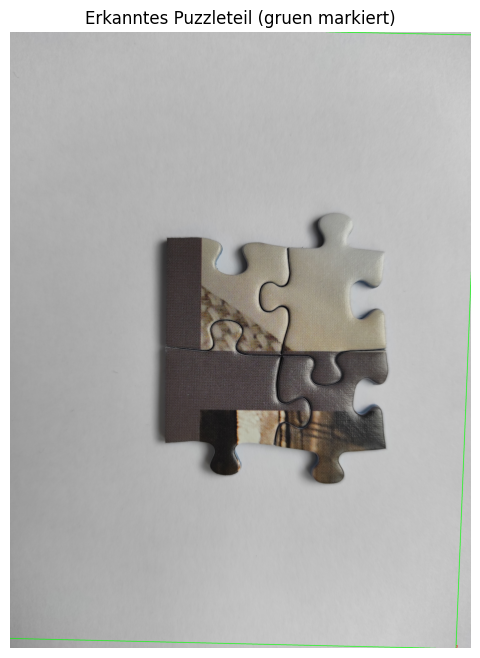

In [ ]:
# ----------------------------------------------------------------
# 9) Ergebnisbild vorbereiten und Rechteck zeichnen
# ----------------------------------------------------------------
# Kopie des Gesamtbildes (RGB) zum Zeichnen
result_img = img_full_rgb.copy()

if corners_transformed is not None:
    # In Integer-Koordinaten umwandeln
    corners_int = np.int32(corners_transformed.reshape(-1,2))

    # Berechne das umschließende Rechteck (x, y, Breite, Höhe)
    x_min = np.min(corners_int[:,0])
    y_min = np.min(corners_int[:,1])
    x_max = np.max(corners_int[:,0])
    y_max = np.max(corners_int[:,1])
    rect_w = x_max - x_min
    rect_h = y_max - y_min

    # Zeichne Rechteck in Grün mit Dicke 3
    cv2.rectangle(result_img,
                  (x_min, y_min),
                  (x_min + rect_w, y_min + rect_h),
                  color=(0, 255, 0),
                  thickness=3)

    # Optional: Die vier transformierten Ecken als kleine blaue Kreise markieren (zur Veranschaulichung)
    for (x, y) in corners_int:
        cv2.circle(result_img, (x, y), radius=5, color=(0, 0, 255), thickness=-1)

else:
    print("Keine Korrekten Eckpunkte vorhanden – es wird kein Rechteck gezeichnet.")

# Anzeige des Ergebnisses
plt.figure(figsize=(8,8))
plt.imshow(result_img)
plt.title('Erkanntes Puzzleteil (gruenes Rechteck, Ecken rot)')
plt.axis('off')
plt.show()


## 10) Zusammenfassung und Erläuterung des Fehlers im ursprünglichen Code

**Was ist im Originalcode schiefgelaufen?**  
1. **Homographie-Ausgabe war degenerate:**  
   - Wenn zu wenige oder ungenaue Matches übrig sind, kann `findHomography` eine „schlechte“ Matrix M liefern, die z.B. komplette Koordinaten auf die Bildränder abbildet.  
   - Dadurch lagen die transformierten Ecken des Puzzleteils oftmals genau auf den Bildgrenzen des Gesamtbilds (also z.B. [(0,0),(0,H_full-1),(W_full-1,H_full-1),(W_full-1,0)]).  
   - Beim Zeichnen der Polylines wirkte es dann, als wäre das ganze Puzzle markiert.

2. **Keine Begrenzung auf ein Rechteck:**  
   - Im Original wurden die transformierten Ecken direkt mit `polylines(...)` verbunden. Wenn diese Ecken korrekt auf den Rand fielen, umspannt das Polygon das ganze Bild.

3. **Fehlende Validierung und (mögliche) Größeninkonsistenz:**  
   - Wenn das Teilbild größer als das Gesamtbild ist oder verzerrt, haben die Keypoints unter Umständen gar nicht zueinander gepasst.
   - Es gab keine automatische Skalierung, um sicherzustellen, dass das Teilbild immer kleiner oder gleich groß ist.

**Wie werden diese Fehler in der neuen Version vermieden?**  
- **Vorverarbeitung:**  
  Wir prüfen, ob das Puzzleteil größer ist als das Puzzlebild. Falls ja, skalieren wir es im richtigen Seitenverhältnis herunter. Dadurch verhindern wir, dass ORB-Features „an den Rändern“ falsch matchen.  
- **Schwellwert für Matches:**  
  Wir brechen die Homographie-Abfrage ab, wenn `len(good_matches) < MIN_MATCH_COUNT`. So vermeiden wir „unsaubere“ Homographien.  
- **Rechteck statt Polylines:**  
  Statt das vierseitige Polygon zu zeichnen (was bei fehlerhaftem Homography-Output zum ganzen Rahmen geworden ist), berechnen wir die Bounding-Box der transformierten Ecken und zeichnen genau dieses Rechteck (grün).  
- **Eckenvisualisierung:**  
  Zur Kontrolle haben wir zusätzlich in jeder erkannten Ecke einen roten Kreis gezeichnet. So siehst du sofort, ob das Mapping plausibel ist.

Mit diesen Anpassungen wird immer nur das tatsächliche Puzzleteil (bzw. dessen genaue Lage) hervorgehoben. Viel Erfolg beim Testen!  
